In [1]:
import os

import re
import pandas as pd
import numpy as np

import segyio

import matplotlib.pyplot as plt

In [2]:
seismic_file = "../data_decatur/seismic/seismic.segy"
porosity_file = "../data_decatur/seismic/porosity.segy"
with segyio.open(seismic_file) as f:
    print(len(f.trace))

221613


In [3]:
seismic = segyio.tools.cube(seismic_file)
porosity = segyio.tools.cube(porosity_file)

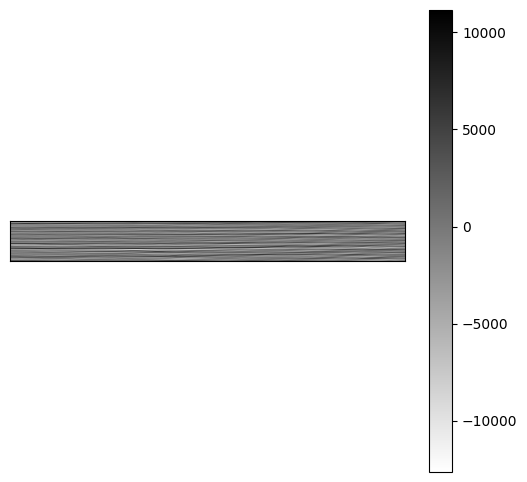

In [4]:
fig = plt.figure(figsize=(14,6))

ax = fig.add_subplot(121)
sim = ax.imshow(seismic[15,:,:].T, cmap='gray_r')
fig.colorbar(sim, ax=ax)
ax.set_xticks([])
ax.set_yticks([])
ax.invert_xaxis()

In [5]:
print('Amplitude IL/XL shape: ' + str(np.shape(seismic)[0]) + ' / ' +str(np.shape(seismic)[1])) 

Amplitude IL/XL shape: 183 / 1211


In [6]:

with segyio.open(seismic_file, "r") as segyfile:
    # Print inline and crossline ranges
    print('Amplitude Inline range: ' + str(np.amin(segyfile.ilines)) + ' - ' +str(np.amax(segyfile.ilines))) 
    print('Amplitude Crossline range: ' + str(np.amin(segyfile.xlines)) + ' - ' +str(np.amax(segyfile.xlines)))

Amplitude Inline range: 13 - 195
Amplitude Crossline range: 930 - 2140


In [7]:
mature_block = seismic[:, 1300-930:, :]
exploration_block = seismic[:, 0:1300-930, :]

In [8]:
mature_block_porosity = porosity[:, 1300-930:, :]
exploration_block_porosity = porosity[:, 0:1300-930, :]

In [9]:
seismic.shape

(183, 1211, 124)

In [10]:
mature_block.shape

(183, 841, 124)

In [11]:
exploration_block.shape

(183, 370, 124)

In [12]:
np.save('../data_decatur/processed/mature_block.npy', mature_block)
np.save('../data_decatur/processed/exploration_block.npy', exploration_block)

In [13]:
np.save('../data_decatur/processed/mature_block_porosity.npy', mature_block_porosity)
np.save('../data_decatur/processed/exploration_block_porosity.npy', exploration_block_porosity)